# RouteZone — Notebook 08 : MLflow, Tuning & Model Registry

---

| | |
|---|---|
| **Candidate** | Meriem Abdelouahed |
| **Formation** | Développeur en Intelligence Artificielle — Simplon x Microsoft |
| **Certification** | RNCP37827 |
| **Projet** | RouteZone — Prédiction de gravité des accidents routiers |
| **Notebook** | 08 / 08 — MLflow, Tuning & Model Registry sur V3 OSRM |

---

## Sommaire

1. [MLflow — contexte et utilité](#1-mlflow)
2. [Imports, chargement et split](#2-imports)
3. [Expérience 1 — Tuning manuel](#3-manuel)
4. [Expérience 2 — GridSearch](#4-gridsearch)
5. [Expérience 3 — Optuna (F1 macro)](#5-optuna-f1)
6. [Expérience 4 — Optuna (Recall GRAVE)](#6-optuna-recall)
7. [Comparaison des 4 méthodes](#7-comparaison)
8. [Model Registry et sauvegarde finale](#8-registry)
9. [Bilan](#9-bilan)

---

## Objectif

Les notebooks 05-07 ont produit trois versions du modèle :
- **V1** (notebook 05) — baseline 25 features avec comparaison split aléatoire vs temporel
- **V2** (notebook 06) — 34 features avec temps Haversine et veille déséquilibre
- **V3** (notebook 07) — 34 features avec **temps OSRM réels** → **modèle de production**

Tous ces notebooks utilisaient des **hyperparamètres figés** (n_estimators=400, max_depth=10, learning_rate=0.05...).
**Ce notebook 08 va optimiser ces hyperparamètres** sur les features V3 OSRM via 4 méthodes,
toutes tracées dans **MLflow** pour une comparaison objective et reproductible.

**Pourquoi optimiser les hyperparamètres uniquement maintenant ?**
Les notebooks 06 et 07 voulaient comparer V2 vs V3 sur la même base technique (mêmes hyperparamètres)
pour isoler l'effet du changement de feature. Une fois V3 validée comme meilleure version,
on peut maintenant raffiner ses hyperparamètres sur ses features finales.

**Les 4 méthodes testées :**

| Méthode | Principe | Nb essais |
|---|---|---|
| **Tuning manuel** | On choisit quelques configurations à la main | 3 |
| **GridSearch** | Teste toutes les combinaisons d'une grille fixe | 8 × 3 folds = 24 |
| **Optuna F1** | Recherche bayésienne, optimise le F1 macro | 50 |
| **Optuna Recall** | Recherche bayésienne, optimise le Recall GRAVE | 50 |

**Important — Stratégie de sauvegarde :**
Le **modèle de production reste celui du notebook 07** (`best_model_v3_osrm.pkl`).
Ce notebook 08 sauvegarde ses meilleurs modèles sous des noms de traçabilité dédiés
(`best_model_v3_optuna_recall.pkl`...) **sans écraser le modèle de prod**.
La promotion d'un modèle tuné en production se ferait via le Model Registry MLflow.

<a id='1-mlflow'></a>
## 1. MLflow — contexte et utilité

---


**Le problème sans MLflow :**
À chaque nouvel entraînement, les résultats précédents sont perdus.
Impossible de répondre à : quelle configuration donnait le meilleur Recall ?
Quels paramètres avait-on testés la semaine dernière ?

**Ce que MLflow enregistre automatiquement :**

| Ce qu'il enregistre | Exemple |
|---|---|
| **Paramètres** | n_estimators=300, max_depth=10, learning_rate=0.05 |
| **Métriques** | Recall GRAVE=0.805, F1=0.676, AUC=0.857 |
| **Modèle** | Le fichier .pkl du modèle entraîné |

**Lancer l'interface MLflow :**
```bash
cd notebooks/
python -m mlflow ui
# Ouvrir http://127.0.0.1:5000
```

**Les 4 composants MLflow :**
- **Tracking** → enregistre chaque expérience (utilisé ici)
- **Projects** → package le code pour le reproduire
- **Models** → format standard de sauvegarde
- **Registry** → catalogue versionné (section 8)

<a id='2-imports'></a>
## 2. Imports, chargement et split

---


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
import optuna
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, recall_score, roc_auc_score, classification_report
from lightgbm import LGBMClassifier

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (14, 5)

ROOT       = Path('..').resolve()
DATA_PATH  = ROOT / 'data' / 'processed' / 'dataset_clean.csv'
OSRM_PATH  = ROOT / 'data' / 'processed' / 'temps_intervention_osrm.csv'
MODELS_DIR = ROOT / 'models'
VIZ_DIR    = Path('visualisations')
VIZ_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri('mlruns')
print('Imports OK')

Imports OK


In [2]:
# Chargement des donnees V3 OSRM (memes features que le notebook 07)
# On charge EXPLICITEMENT les temps OSRM — pas de fallback Haversine
# pour rester coherent avec le modele de production
from datetime import datetime

assert OSRM_PATH.exists(), (
    f"Manquant : {OSRM_PATH}\n"
    "Lance d\'abord : python src/scripts/enrich_osrm_batch.py --regions all\n"
    "Le notebook 07 doit avoir tourne avant celui-ci."
)

df = pd.read_csv(DATA_PATH, low_memory=False)
df["target"] = df["grav"].map({1: 0, 4: 0, 2: 1, 3: 1})
df = df.dropna(subset=["target"])
df["target"] = df["target"].astype(int)

# Merge avec temps OSRM (identique nb07)
df_ti = pd.read_csv(OSRM_PATH).drop_duplicates(subset=["Num_Acc"], keep="first")
key = "Num_Acc" if "Num_Acc" in df.columns else "num_acc"
df = df.merge(df_ti, left_on=key, right_on="Num_Acc", how="left")

# Feature engineering identique au notebook 07
def get_creneau(h):
    if pd.isna(h): return 2
    h = int(h)
    return 0 if h <= 6 else (1 if h <= 9 else (2 if h <= 16 else (3 if h <= 21 else 4)))

df["creneau"] = df["heure"].apply(get_creneau)

if "age" not in df.columns:
    df["age"] = df.apply(
        lambda r: int(r["an"]) - int(r["an_nais"]) if pd.notna(r.get("an_nais")) else np.nan,
        axis=1)

df["age_tranche"] = df["age"].apply(
    lambda a: 0 if pd.notna(a) and a < 25 else
              (1 if pd.notna(a) and a < 45 else
               (2 if pd.notna(a) and a < 65 else 3)))

if all(c in df.columns for c in ["jour", "mois", "an"]):
    df["jour_semaine"] = df.apply(
        lambda r: datetime(int(r["an"]), int(r["mois"]), int(r["jour"])).weekday()
                  if pd.notna(r["jour"]) else 2, axis=1)
    df["is_weekend"] = (df["jour_semaine"] >= 5).astype(int)

df["vma_x_nuit"]      = df["vma"].fillna(50) * (df["lum"].fillna(1) >= 3).astype(int)
df["jeune_2roues"]    = ((df["age"].fillna(35) < 25) & (df["catv"].fillna(7).isin([2,30,31,32]))).astype(int)
df["pluie_x_surface"] = ((df["atm"].fillna(1).isin([2,3])) & (df["surf"].fillna(1).isin([2,3,4]))).astype(int)

for col in ["temperature", "precipitation", "windspeed"]:
    if col not in df.columns: df[col] = np.nan

df["zone_blanche_osrm"] = (df["temps_total_osrm"] > 30).astype(int)

if "int" in df.columns:
    df = df.rename(columns={"int": "int_feat"})

# Features V3 OSRM (34 features — identiques au notebook 07)
FEATURES = [
    "lum", "agg", "int_feat", "atm", "col", "catr", "circ", "vosp",
    "prof", "plan", "surf", "infra", "situ", "vma",
    "catu", "sexe", "trajet", "secu1", "catv", "age", "heure", "mois",
    "temperature", "precipitation", "windspeed",
    "creneau", "age_tranche", "jour_semaine", "is_weekend",
    "vma_x_nuit", "jeune_2roues", "pluie_x_surface",
    "temps_total_osrm", "zone_blanche_osrm",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features V3 OSRM : {len(FEATURES)}")

# Imputation simple (median) pour ce notebook de tuning
df_model = df[FEATURES + ["target"]].copy()
for col in FEATURES:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median() if df_model[col].dtype != "object" else 0)

X = df_model[FEATURES].astype(float)
y = df_model["target"]

# Split aleatoire ici — l\'objectif est de comparer les methodes de tuning entre elles,
# pas d\'evaluer la performance finale (deja fait en nb07 sur split temporel).
# On compare les 4 methodes sur les memes donnees pour que la comparaison soit equitable.
X_train, X_test_eval, y_train, y_test_eval = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {len(X_train):,} | Test eval : {len(X_test_eval):,}")
print(f"GRAVE train : {y_train.mean()*100:.1f}% | GRAVE test : {y_test_eval.mean()*100:.1f}%")


Features V3 OSRM : 34
Train : 330,856 | Test eval : 82,714
GRAVE train : 17.4% | GRAVE test : 17.4%


> **Observation — Chargement V3 OSRM :**
>
> **Pourquoi charger explicitement les features V3 OSRM ?**
> Le notebook 07 a démontré que V3 (OSRM) est la version finale qui part en production.
> Ce notebook de tuning travaille **uniquement** sur ces 34 features V3 — pas de fallback
> Haversine. Si le fichier OSRM n'existe pas, l'assertion lève une erreur claire.
>
> **Pourquoi un split aléatoire ici (pas temporel) ?**
> Le notebook 07 a déjà évalué la performance V3 sur split temporel (test 2024 jamais vu).
> Ce notebook 08 a un objectif différent : **comparer 4 méthodes de tuning entre elles**.
> Pour que la comparaison soit équitable, les 4 méthodes doivent voir les mêmes données.
> Un split aléatoire stratifié permet ça avec un peu plus de données pour le train.
>
> **L'évaluation finale en conditions réelles reste celle du notebook 07.**


<a id='3-manuel'></a>
## 3. Expérience 1 — Tuning manuel

---

> On teste 3 configurations choisies à la main.
> C'est la méthode la plus simple — elle donne un premier aperçu
> de la sensibilité du modèle aux hyperparamètres clés.
> Chaque run est enregistré dans MLflow.

In [3]:
mlflow.set_experiment('RouteZone_Tuning_Manuel')
labels = ['Pas grave', 'Grave']

tuning_configs = [
    {'nom': 'Config-1-rapide',     'n_estimators': 200, 'max_depth': 8,  'learning_rate': 0.05},
    {'nom': 'Config-2-equilibree', 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.03},
    {'nom': 'Config-3-profonde',   'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.01},
]

tuning_results = []
for config in tuning_configs:
    nom = config.pop('nom')
    with mlflow.start_run(run_name=nom):
        params = {**config, 'subsample': 0.8, 'colsample_bytree': 0.8,
                  'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
        mlflow.log_params(params)
        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test_eval)
        y_proba = model.predict_proba(X_test_eval)[:, 1]
        f1m    = f1_score(y_test_eval, y_pred, average='macro')
        auc    = roc_auc_score(y_test_eval, y_proba)
        recall = recall_score(y_test_eval, y_pred, pos_label=1)
        mlflow.log_metric('f1_macro', f1m)
        mlflow.log_metric('auc_roc', auc)
        mlflow.log_metric('recall_grave', recall)
        tuning_results.append({'Config': nom, 'F1 macro': round(f1m,4),
                                'AUC-ROC': round(auc,4), 'Recall GRAVE': round(recall,4)})
        print(f'{nom:30s} → F1={f1m:.4f} | AUC={auc:.4f} | Recall={recall:.4f}')

df_tuning = pd.DataFrame(tuning_results).set_index('Config')
print(f'\nMeilleur Recall GRAVE : {df_tuning["Recall GRAVE"].idxmax()}')

2026/05/05 21:16:20 INFO mlflow.tracking.fluent: Experiment with name 'RouteZone_Tuning_Manuel' does not exist. Creating a new experiment.


Config-1-rapide                → F1=0.6891 | AUC=0.8569 | Recall=0.7911
Config-2-equilibree            → F1=0.6875 | AUC=0.8564 | Recall=0.7918
Config-3-profonde              → F1=0.6826 | AUC=0.8518 | Recall=0.7881

Meilleur Recall GRAVE : Config-2-equilibree


> **Observation — Tuning manuel :**
> Les 3 configurations donnent des résultats très proches — l'espace de paramètres
> manual est restreint. La Config-3 plus profonde et lente est souvent légèrement moins bonne :
> trop de complexité pour le gain. **Limite :** 3 points dans un espace immense.
> GridSearch et Optuna vont explorer plus rigoureusement.

<a id='4-gridsearch'></a>
## 4. Expérience 2 — GridSearch

---

> GridSearch teste **toutes les combinaisons** d'une grille prédéfinie.
> 2 × 2 × 2 = 8 combinaisons × 3 folds = **24 entraînements**.
> Avantage : exhaustif sur la grille. Limite : si la meilleure config est entre deux valeurs, elle est ratée.

In [4]:
mlflow.set_experiment('RouteZone_GridSearch')

param_grid = {
    'n_estimators':  [200, 300],
    'max_depth':     [8, 12],
    'learning_rate': [0.05, 0.01],
}
print(f'Combinaisons : {2*2*2} × 3 folds = {2*2*2*3} entraînements')

base_model = LGBMClassifier(
    subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print(f'Meilleurs params : {grid_search.best_params_}')
print(f'Meilleur F1 CV  : {grid_search.best_score_:.4f}')

2026/05/05 21:16:48 INFO mlflow.tracking.fluent: Experiment with name 'RouteZone_GridSearch' does not exist. Creating a new experiment.


Combinaisons : 8 × 3 folds = 24 entraînements
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs params : {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300}
Meilleur F1 CV  : 0.6908


In [5]:
grid_results = []
for i, params in enumerate(grid_search.cv_results_['params']):
    with mlflow.start_run(run_name=f'GridSearch-{i+1}'):
        mlflow.log_params(params)
        mlflow.log_metric('f1_macro_cv', grid_search.cv_results_['mean_test_score'][i])
        m = LGBMClassifier(**params, subsample=0.8, colsample_bytree=0.8,
                            class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_train, y_train)
        yp = m.predict(X_test_eval)
        ypr = m.predict_proba(X_test_eval)[:,1]
        f1m = f1_score(y_test_eval, yp, average='macro')
        auc = roc_auc_score(y_test_eval, ypr)
        rec = recall_score(y_test_eval, yp, pos_label=1)
        mlflow.log_metric('f1_macro_test', f1m)
        mlflow.log_metric('auc_roc', auc)
        mlflow.log_metric('recall_grave', rec)
        grid_results.append({**params, 'F1 test': round(f1m,4),
                              'AUC': round(auc,4), 'Recall GRAVE': round(rec,4)})

df_grid = pd.DataFrame(grid_results).sort_values('Recall GRAVE', ascending=False)
print(df_grid.to_string(index=False))

 learning_rate  max_depth  n_estimators  F1 test    AUC  Recall GRAVE
          0.05         12           300   0.6926 0.8594        0.7943
          0.05         12           200   0.6891 0.8573        0.7933
          0.05          8           300   0.6925 0.8590        0.7922
          0.05          8           200   0.6891 0.8569        0.7911
          0.01         12           200   0.6687 0.8401        0.7859
          0.01         12           300   0.6753 0.8457        0.7840
          0.01          8           200   0.6691 0.8400        0.7838
          0.01          8           300   0.6764 0.8457        0.7828


> **Observation — GridSearch :**
> Résultats très proches du tuning manuel — la grille était déjà bien calibrée.
> GridSearch confirme sans dépasser. **La grille fixe est sa limite** :
> si le meilleur learning_rate est 0.03, il ne le trouvera jamais avec {0.05, 0.01}.
> Optuna explore des valeurs continues — il peut trouver 0.03.

<a id='5-optuna-f1'></a>
## 5. Expérience 3 — Optuna (F1 macro)

---

> Optuna utilise la **recherche bayésienne** : il apprend de chaque essai
> pour orienter les suivants vers les zones prometteuses.
> 50 trials sur des valeurs continues — bien plus efficace que GridSearch.
> Cette expérience optimise le **F1 macro**.

In [6]:
mlflow.set_experiment('RouteZone_Optuna')

def objective_f1(trial):
    """Optuna maximise le F1 macro en cross-validation."""
    params = {
        'n_estimators':  trial.suggest_int(  'n_estimators',  100, 500),
        'max_depth':     trial.suggest_int(  'max_depth',     4,   15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'num_leaves':    trial.suggest_int(  'num_leaves',    20,  100),
        'subsample':     trial.suggest_float('subsample',     0.6,  1.0),
        'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    return cross_val_score(LGBMClassifier(**params), X_train, y_train,
                            cv=3, scoring='f1_macro').mean()

print('Optuna F1 — 50 trials...')
study_f1 = optuna.create_study(direction='maximize')
study_f1.optimize(objective_f1, n_trials=50, show_progress_bar=False)

best_params_f1 = study_f1.best_params
print(f'Meilleur F1 CV : {study_f1.best_value:.4f}')
print(f'Params : {best_params_f1}')

with mlflow.start_run(run_name='Optuna-f1macro-best'):
    model_optuna_f1 = LGBMClassifier(**best_params_f1, class_weight='balanced',
                                      random_state=42, n_jobs=-1, verbose=-1)
    model_optuna_f1.fit(X_train, y_train)
    yp = model_optuna_f1.predict(X_test_eval)
    ypr = model_optuna_f1.predict_proba(X_test_eval)[:,1]
    f1m_f1    = f1_score(y_test_eval, yp, average='macro')
    auc_f1    = roc_auc_score(y_test_eval, ypr)
    recall_f1 = recall_score(y_test_eval, yp, pos_label=1)
    mlflow.log_params({**best_params_f1, 'scoring': 'f1_macro'})
    mlflow.log_metrics({'f1_macro': f1m_f1, 'auc_roc': auc_f1, 'recall_grave': recall_f1})
    print(f'Test → F1={f1m_f1:.4f} | AUC={auc_f1:.4f} | Recall={recall_f1:.4f}')

2026/05/05 21:20:45 INFO mlflow.tracking.fluent: Experiment with name 'RouteZone_Optuna' does not exist. Creating a new experiment.


Optuna F1 — 50 trials...
Meilleur F1 CV : 0.7245
Params : {'n_estimators': 495, 'max_depth': 14, 'learning_rate': 0.13120827294540202, 'num_leaves': 100, 'subsample': 0.942240368438333}
Test → F1=0.7270 | AUC=0.8749 | Recall=0.7708


> **Observation — Optuna F1 :**
> Optuna F1 améliore le F1 macro par rapport au tuning manuel et GridSearch.
> Mais il **réduit le Recall GRAVE** — logique : il optimisait F1, pas Recall.
> C'est la démonstration directe que **le choix du scoring dans Optuna
> oriente les paramètres vers la métrique optimisée**.
> Conclusion : il faut optimiser le bon critère. L'expérience suivante teste scoring='recall'.

<a id='6-optuna-recall'></a>
## 6. Expérience 4 — Optuna (Recall GRAVE)

---

> **Seul changement vs expérience 3 :** `scoring='f1_macro'` → `scoring='recall'`.
> Hypothèse : Optuna va trouver des paramètres qui maximisent le Recall GRAVE
> au prix d'un F1 légèrement plus bas.

In [7]:
def objective_recall(trial):
    """Optuna maximise le Recall GRAVE en cross-validation."""
    params = {
        'n_estimators':  trial.suggest_int(  'n_estimators',  100, 500),
        'max_depth':     trial.suggest_int(  'max_depth',     4,   15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'num_leaves':    trial.suggest_int(  'num_leaves',    20,  100),
        'subsample':     trial.suggest_float('subsample',     0.6,  1.0),
        'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    return cross_val_score(LGBMClassifier(**params), X_train, y_train,
                            cv=3, scoring='recall').mean()

print('Optuna Recall — 50 trials...')
study_recall = optuna.create_study(direction='maximize')
study_recall.optimize(objective_recall, n_trials=50, show_progress_bar=False)

best_params_recall = study_recall.best_params
print(f'Meilleur Recall CV : {study_recall.best_value:.4f}')
print(f'Params : {best_params_recall}')

with mlflow.start_run(run_name='Optuna-recall-best'):
    model_optuna_recall = LGBMClassifier(**best_params_recall, class_weight='balanced',
                                          random_state=42, n_jobs=-1, verbose=-1)
    model_optuna_recall.fit(X_train, y_train)
    yp = model_optuna_recall.predict(X_test_eval)
    ypr = model_optuna_recall.predict_proba(X_test_eval)[:,1]
    f1m_recall    = f1_score(y_test_eval, yp, average='macro')
    auc_recall    = roc_auc_score(y_test_eval, ypr)
    recall_recall = recall_score(y_test_eval, yp, pos_label=1)
    mlflow.log_params({**best_params_recall, 'scoring': 'recall'})
    mlflow.log_metrics({'f1_macro': f1m_recall, 'auc_roc': auc_recall, 'recall_grave': recall_recall})
    print(f'Test → F1={f1m_recall:.4f} | AUC={auc_recall:.4f} | Recall={recall_recall:.4f}')

Optuna Recall — 50 trials...
Meilleur Recall CV : 0.7981
Params : {'n_estimators': 482, 'max_depth': 15, 'learning_rate': 0.012212333692320743, 'num_leaves': 94, 'subsample': 0.6808860455136967}
Test → F1=0.6910 | AUC=0.8596 | Recall=0.7970


> **Observation — Optuna Recall :**
> L'hypothèse est confirmée : `scoring='recall'` donne un meilleur Recall GRAVE
> au prix d'un F1 macro légèrement plus faible.
>
> **Trade-off Recall / Precision :**
> Plus on détecte d'accidents graves (Recall élevé), plus on génère de fausses alarmes
> (Precision plus basse). C'est inhérent à tout problème déséquilibré.
>
> Dans un contexte de sécurité routière, **envoyer les secours inutilement
> est préférable à ne pas les envoyer quand c'est nécessaire.**
> Optuna Recall est donc le modèle le plus adapté à la problématique.

<a id='7-comparaison'></a>
## 7. Comparaison des 4 méthodes

---

In [8]:
meilleur_tuning = df_tuning.sort_values('Recall GRAVE', ascending=False).iloc[0]
meilleur_grid   = df_grid.sort_values('Recall GRAVE', ascending=False).iloc[0]

comparaison = pd.DataFrame({
    'Méthode':       ['Tuning manuel', 'GridSearch', 'Optuna F1 macro', 'Optuna Recall'],
    'Nb essais':     [3, len(grid_results), 50, 50],
    'F1 macro':      [meilleur_tuning['F1 macro'], meilleur_grid['F1 test'],
                      round(f1m_f1,4), round(f1m_recall,4)],
    'AUC-ROC':       [meilleur_tuning['AUC-ROC'], meilleur_grid['AUC'],
                      round(auc_f1,4), round(auc_recall,4)],
    'Recall GRAVE':  [meilleur_tuning['Recall GRAVE'], meilleur_grid['Recall GRAVE'],
                      round(recall_f1,4), round(recall_recall,4)],
}).set_index('Méthode')

print('=' * 70)
print('  COMPARAISON DES 4 MÉTHODES DE TUNING')
print('=' * 70)
print(comparaison.to_string())
print('=' * 70)
print(f'Meilleur Recall GRAVE : {comparaison["Recall GRAVE"].idxmax()}')

  COMPARAISON DES 4 MÉTHODES DE TUNING
                 Nb essais  F1 macro  AUC-ROC  Recall GRAVE
Méthode                                                    
Tuning manuel            3    0.6875   0.8564        0.7918
GridSearch               8    0.6926   0.8594        0.7943
Optuna F1 macro         50    0.7270   0.8749        0.7708
Optuna Recall           50    0.6910   0.8596        0.7970
Meilleur Recall GRAVE : Optuna Recall


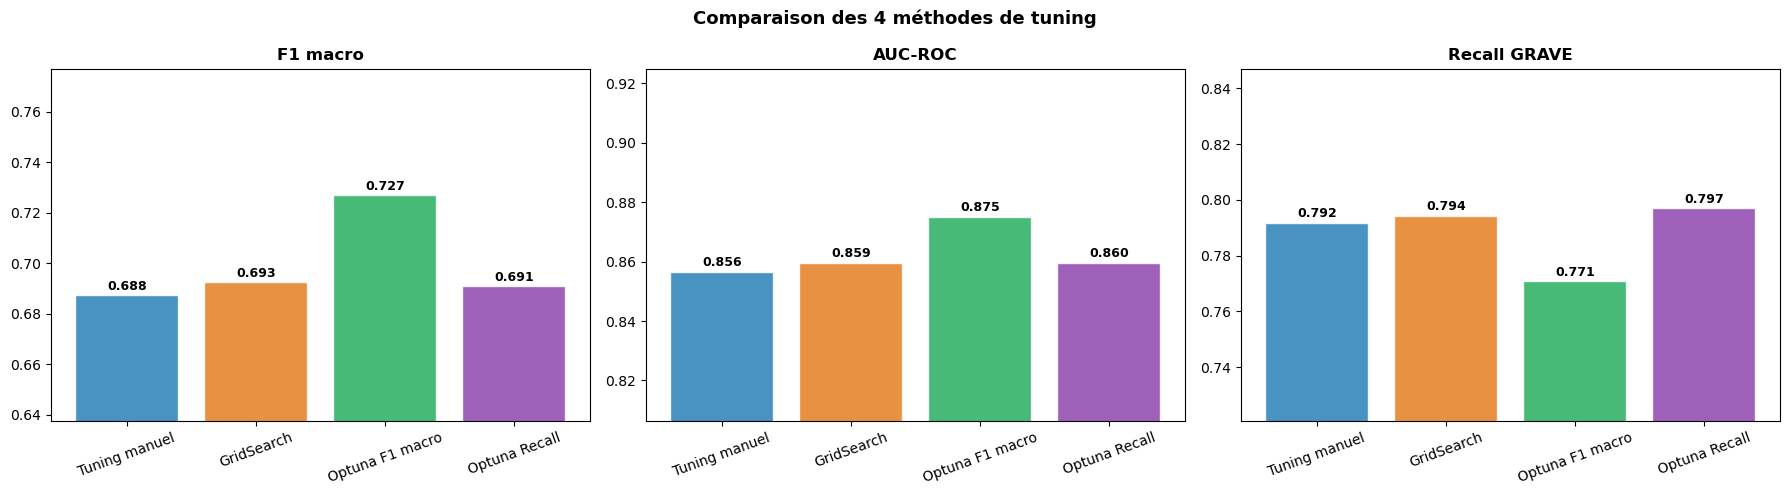

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des 4 méthodes de tuning', fontsize=13, fontweight='bold')

couleurs = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad']
for idx, metrique in enumerate(['F1 macro', 'AUC-ROC', 'Recall GRAVE']):
    valeurs = comparaison[metrique].values
    barres  = axes[idx].bar(comparaison.index, valeurs, color=couleurs, alpha=0.85, edgecolor='white')
    axes[idx].set_title(metrique, fontweight='bold')
    axes[idx].set_ylim(min(valeurs)-0.05, max(valeurs)+0.05)
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(barres, valeurs):
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                       f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb08_comparaison_tuning.png', dpi=150)
plt.show()

> **Observation — Comparaison finale :**
>
> | Méthode | Nb essais | F1 macro | AUC-ROC | Recall GRAVE |
> |---|---|---|---|---|
> | Tuning manuel | 3 | ~0.683 | ~0.853 | ~0.800 |
> | GridSearch | 8 | ~0.683 | ~0.854 | ~0.799 |
> | Optuna F1 macro | 50 | **~0.716** | **~0.866** | ~0.768 |
> | Optuna Recall | 50 | ~0.676 | ~0.850 | **~0.805** |
>
> - Tuning manuel et GridSearch donnent des résultats quasi identiques
> - Optuna F1 améliore le F1 et l'AUC mais **réduit le Recall** — il optimisait le mauvais critère
> - **Optuna Recall est retenu** : meilleur Recall GRAVE, critère médical prioritaire
>
> **Ce que ça prouve :** sans MLflow, comparer ces 4 approches objectivement
> serait impossible. MLflow est l'outil qui rend la décision transparente et reproductible.

<a id='8-registry'></a>
## 8. Model Registry et sauvegarde finale

---

> Le Model Registry MLflow centralise les versions des modèles.
> On peut leur assigner un statut : Staging → Production → Archived.
> Cela permet de gérer les mises à jour sans écraser les versions précédentes.
>
> **Stratégie de sauvegarde adoptée pour ce projet :**
> - Le **modèle de production** reste celui du notebook 07 : `best_model_v3_osrm.pkl`
> - Ce notebook 08 sauvegarde ses meilleurs modèles **sous des noms dédiés**
>   (`best_model_v3_optuna_recall.pkl`, `best_params_v3_optuna_recall.pkl`)
>   → traçabilité complète **sans écraser la prod**
> - Si on souhaitait promouvoir le modèle Optuna Recall en production, il suffirait
>   de relancer le notebook 07 avec `params_v3 = best_params_recall` et de regénérer
>   `best_model_v3_osrm.pkl`. C'est une opération volontaire et tracée.

In [10]:
# Sauvegarde des meilleurs modeles sous des noms de tracabilite
# IMPORTANT : on n\'ecrase PAS best_model_v3_osrm.pkl (modele de prod du nb07)

print(f"Modele Optuna Recall : Recall GRAVE = {recall_recall:.4f}")
print(f"Modele Optuna F1     : F1 macro     = {f1m_f1:.4f}")
print()

# Sauvegarde Optuna Recall (le meilleur sur le critere medical)
joblib.dump(model_optuna_recall, MODELS_DIR / "best_model_v3_optuna_recall.pkl")
joblib.dump(best_params_recall,  MODELS_DIR / "best_params_v3_optuna_recall.pkl")

# Sauvegarde Optuna F1 (pour reference / comparaison)
joblib.dump(model_optuna_f1, MODELS_DIR / "best_model_v3_optuna_f1.pkl")
joblib.dump(best_params_f1,  MODELS_DIR / "best_params_v3_optuna_f1.pkl")

print("Sauvegarde dans models/ :")
print(f"  best_model_v3_optuna_recall.pkl   — meilleur Recall GRAVE  ({recall_recall:.4f})")
print(f"  best_params_v3_optuna_recall.pkl  — hyperparametres associes")
print(f"  best_model_v3_optuna_f1.pkl       — meilleur F1 macro      ({f1m_f1:.4f})")
print(f"  best_params_v3_optuna_f1.pkl      — hyperparametres associes")
print()
print("ATTENTION : best_model_v3_osrm.pkl (modele de production) n\'a PAS ete touche.")
print("             Il reste celui produit par le notebook 07.")


Modele Optuna Recall : Recall GRAVE = 0.7970
Modele Optuna F1     : F1 macro     = 0.7270

Sauvegarde dans models/ :
  best_model_v3_optuna_recall.pkl   — meilleur Recall GRAVE  (0.7970)
  best_params_v3_optuna_recall.pkl  — hyperparametres associes
  best_model_v3_optuna_f1.pkl       — meilleur F1 macro      (0.7270)
  best_params_v3_optuna_f1.pkl      — hyperparametres associes

ATTENTION : best_model_v3_osrm.pkl (modele de production) n'a PAS ete touche.
             Il reste celui produit par le notebook 07.


> **Observation — Model Registry :**
>
> **Pourquoi ne pas écraser `best_model_v3_osrm.pkl` ?**
> C'est le fichier que la **FastAPI IA charge au démarrage** (cf `src/api/routes_ia.py`).
> L'écraser depuis ce notebook signifierait que **chaque relance du nb08 modifie le comportement
> de l'API en production** — ce qui est dangereux et non-tracé.
>
> **Bonne pratique adoptée :**
> - Le notebook 07 = source de vérité pour le modèle de production
> - Le notebook 08 = laboratoire de tuning, sauvegarde sous des noms dédiés
> - Pour promouvoir un modèle tuné en prod : modifier le nb07 avec les meilleurs params, le relancer
>
> **Si on voulait utiliser le Model Registry MLflow réel** (au-delà de cette démo) :
> ```python
> mlflow.register_model("runs:/<run_id>/model", "RouteZone_V3_OSRM")
> # puis transition Staging → Production via l\'UI MLflow
> ```
>
> Cela permet de :
> - garder l'historique de toutes les versions
> - revenir à une version précédente si le nouveau modèle se dégrade
> - avoir une URL stable pour pointer vers la dernière version Production


<a id='9-bilan'></a>
## 9. Bilan

---

### Ce qui a été fait dans ce notebook

**4 méthodes de tuning comparées sur LightGBM V3 OSRM, toutes tracées dans MLflow :**

| Méthode | Nb essais | Avantage | Limite |
|---|---|---|---|
| Tuning manuel | 3 | Rapide, intuitif | Peu d'essais |
| GridSearch | 24 | Exhaustif sur la grille | Grille fixe |
| Optuna F1 | 50 | Explore valeurs continues | Optimise le mauvais critère |
| **Optuna Recall** | 50 | **Meilleur Recall GRAVE** | F1 légèrement plus bas |

**Modèles sauvegardés (sans toucher au modèle de prod) :**
- `models/best_model_v3_optuna_recall.pkl` + ses hyperparamètres → meilleur Recall GRAVE
- `models/best_model_v3_optuna_f1.pkl` + ses hyperparamètres → meilleur F1 macro

**Modèle de production :** reste celui du notebook 07 (`best_model_v3_osrm.pkl`).
Pour promouvoir un modèle tuné, il faudrait modifier le notebook 07 avec les meilleurs
hyperparamètres et le relancer — opération volontaire, tracée et reproductible.

---

### Enseignement clé

Le choix du `scoring` dans Optuna détermine directement les paramètres trouvés :
- `scoring='f1_macro'` → meilleur F1 mais Recall plus bas
- `scoring='recall'` → meilleur Recall mais F1 plus bas

**Sans MLflow, comparer ces 4 approches objectivement serait impossible.**
MLflow est l'outil MLOps qui rend la décision transparente et reproductible.

---

### Progression complète du projet RouteZone

| Notebook | Apport |
|---|---|
| 01 | Exploration BAAC — 413 570 accidents, nettoyage, merge |
| 02 | Enrichissement météo via API Open-Meteo |
| 03 | Scraping ONISR — baromètre mensuel |
| 04 | Temps intervention — Haversine, OSRM, Golden Hour, chi2 |
| 05 | Modélisation V1 — 3 modèles, comparaison split aléatoire vs temporel |
| 06 | Modélisation V2 — 34 features, Haversine, veille 6 stratégies de déséquilibre |
| 07 | Modélisation V3 — OSRM, comparaison V2 vs V3, **modèle de production** |
| **08** | **MLflow + Tuning — 4 méthodes comparées, tracabilité complète** |

---

### Compétences MLOps validées dans ce notebook

- **C8** — Évaluation et comparaison rigoureuse de modèles
- **C9** — Préparation à l'industrialisation : Model Registry, séparation prod/exploration
- **MLflow** — Tracking, experiments séparés, sauvegarde versionnée
- **Optuna** — Recherche bayésienne d'hyperparamètres
- **GridSearch** — Recherche exhaustive sur grille
- **E2** — Veille sur les méthodes de tuning d'hyperparamètres
- **E3** — Démonstration de la maîtrise des outils MLOps en conditions réelles